# Relatório Preliminar – Diárias e Passagens (Opção A: Regressão)

**Renê Estevam Deckers** - Introdução a Machine Learning

Este relatório segue a estrutura do **template da disciplina** (relatório preliminar – Fase 1), adaptada ao contexto do **SCDP** (Sistema de Custos de Diárias e Passagens) e à **Opção A** de modelagem: regressão para previsão do valor da despesa.

---

## 1. Descrição da Base de Dados

* ### **Fonte dos dados:**  
  Base obtida em **dados abertos do governo federal**, via Portal da Transparência e conjunto *Viagens a Serviço do Governo Federal (SCDP)* em [dados.gov.br](https://dados.gov.br/dados/conjuntos-dados/viagens-a-servico-do-governo-federal-scdp). O arquivo utilizado é o CSV **DiariasEPassagens_ultimos_2_anos.csv**, contendo registros de diárias e passagens dos **últimos 2 anos** da administração pública federal (Poder Executivo).

* ### **Contextualização:**  
  Cada **linha** representa um **trecho de viagem** ou um lançamento de diária: está vinculada a um servidor, a um órgão (e unidade gestora), às datas de início e término da viagem, ao **motivo** oficial, aos valores em reais (valor total, valor de diárias, valor de passagem) e ao **meio de transporte** quando há deslocamento. Pode haver **múltiplas linhas por viagem** (vários trechos ou lançamentos separados de diária e passagem). A base permite analisar padrões de gastos por órgão, motivo, meio de transporte e período, com relevância para **transparência**, **controle de custos** e **sustentabilidade** (redução de viagens e preferência por meios menos poluentes).

* ### **Enquadramento institucional — o que são viagens a serviço:**  
  Na **Administração Pública Federal Direta, fundações e autarquias**, viagens a serviço são **afastamentos** de servidores, militares, empregados públicos e colaboradores eventuais, em caráter **eventual ou transitório**, no território **nacional ou exterior**, período em que fazem jus a **passagens e diárias**. Esses valores **indenizam despesas extraordinárias** com pousada, alimentação e locomoção urbana, conforme a **Lei nº 8.112, de 1990**. Assim, **Valor total**, **Valor diárias** e **Valor passagem** referem-se a **custos de viagens institucionais**, não a gastos genéricos do órgão.

* ### **Como diárias e passagens entram nos registros (SCDP):**  
  O CSV traz **lançamentos** sujeitos a regras de sistema e de pagamento, e não apenas "a viagem" como fenômeno isolado:
  - Em geral há **data de início da viagem** na linha, mas os **valores monetários** podem corresponder a **outro momento** (pagamento ou registro administrativo).
  - **Viagens sigilosas:** em dados públicos, informações podem surgir **somente após o encerramento** do período de sigilo.
  - **Diárias:** costumam refletir situações em que houve **efetivação do pagamento** da parcela no **sistema financeiro** do governo.
  - **Passagens:** costumam aparecer em função do **registro da emissão** no **SCDP**.  
  Na **regressão**, o modelo só observa o que está na tabela: agregações por mês ou interpretações temporais devem considerar que o **alvo** pode estar mais ligado ao **fluxo de pagamento/registro** do que exclusivamente ao calendário de início da viagem.

* ### **SIAFI e outras fontes — contexto (não faz parte do escopo deste arquivo):**  
  O **SIAFI** (Sistema Integrado de Administração Financeira do Governo Federal) tem **lógica própria** de registro; há **órgãos que não utilizam o SCDP**. Em viagens **sigilosas**, despesas podem ser pagas/registradas no SIAFI enquanto, em bases públicas ligadas ao SCDP/transparência, a **mesma informação** pode só constar **depois** do fim do sigilo. **Este relatório** utiliza **apenas** o CSV dos **dados abertos** do conjunto SCDP; qualquer comparação futura com SIAFI exigiria critérios alinhados (datas, órgãos, definições de diária/passagem).

* ### **Implicações para as análises deste notebook:**  
  - **Lei 8.112/1990** dá significado normativo às variáveis de valor (boa base para interpretar o **target**).
  - **Datas** na base vs. momento de pagamento/registro → possível **desalinhamento temporal**; interpretar gráficos e uso de datas como *features* com cuidado.
  - **Sigilo** pode atrasar a presença de algumas linhas em bases públicas (relevante para leituras longitudinais).
  - O **Valor total** (e afins) pode refletir **eventos administrativos**, não só características "físicas" da viagem.
  - **Escopo explícito:** arquivo exportado **dados.gov.br (SCDP)**; não extrapolar totais para outros sistemas sem harmonização.

* ### **Objetivo da utilização:**  
  Analisar padrões de gastos e preparar a **modelagem de regressão** para **prever o valor da despesa** (valor total do registro, ou valor de diárias/passagens), com vistas a orçamento, metas de redução de custos e apoio à auditoria.

* ### **Problema de pesquisa:**  
  *É possível prever o valor total da despesa (ou o valor de diárias/passagens) a partir de características da viagem e do órgão?*  
  Tipo de aprendizado: **supervisionado — Regressão**.

* ### **O que vai prever?**  
  **Variável alvo (target):** **Valor total** (em R$), representando o custo total do registro (diárias + passagens). Alternativas para análises futuras: Valor diárias ou Valor passagem em subconjuntos específicos da base.

---

## 2. Dicionário de Dados

O dicionário de dados deve ser entregue **em arquivo separado (Excel)**.

O dicionário de dados foi gerado conforme o template (arquivo separado).  
- **Arquivo Excel (entrega):** `dicionario_dados.xlsx` — contém as **23 variáveis** da base, com colunas: ordem (#), Nome do campo, Tipo sugerido, Unidade ou valores, Descrição.  
- **Arquivo CSV (mesmo conteúdo):** `dicionario_dados.csv` — mesmo dicionário em formato texto (separador `;`) para versionamento e abertura em planilhas.  
- **Conteúdo:** para cada variável: tipo (numérico/categórico/data), unidade de medida e significado.

A base possui **23 variáveis**. Abaixo, resumo das mais relevantes para a **Opção A (regressão)**:

| Variável | Tipo | Unidade / valores | Observação |
|----------|------|-------------------|------------|
| Valor total | Numérico | R$ | **Variável alvo** do modelo de regressão. |
| Valor diárias | Numérico | R$ | Candidata a target ou feature; formato original pode usar vírgula decimal. |
| Valor passagem | Numérico | R$ | Candidata a target ou feature; zero quando não há passagem. |
| Número diárias | Numérico | Quantidade | Forte candidata a preditora. |
| Data início/término viagem | Data/datetime | AAAA-MM-DD (e hora) | Permitem derivar duração, mês e ano. |
| Motivo | Categórico | Texto (ex.: Nacional - A Serviço, Audiência) | Preditora após encoding. |
| Meio de transporte | Categórico | Ex.: Aéreo, Rodoviário, Veículo Oficial | Preditora; relevante para sustentabilidade. |
| Código/Nome órgão (superior, órgão, unidade gestora) | Numérico / Categórico | Códigos e nomes | Identificação do órgão; uso como feature pode exigir agrupamento. |
| Município/UF origem e destino | Categórico | Texto / sigla UF | Muitos nulos quando o registro é apenas diária (sem trecho de passagem). |
| Cargo, Categoria passagem | Categórico | Texto | Cargo com muitos nulos; Categoria passagem nula quando não há passagem. |

A descrição **completa** das 23 variáveis (tipo, unidade e significado) está no documento `pre_projeto_diarias_passagens.md` (Seção 4) e deve ser reproduzida no arquivo Excel anexo.

---

## 3. Análises Descritivas Iniciais

### 3.1 Medidas de Posição e Dispersão

Objetivo: obter **tabelas e resumos estatísticos** para as variáveis numéricas principais, incluindo:

- **Posição:** média, mediana, mínimo, máximo, quartis (Q1, Q3).  
- **Dispersão:** desvio-padrão e **coeficiente de variação (CV%)** — útil para comparar variabilidade entre variáveis com escalas diferentes (ex.: Valor total em R$ vs. Número diárias em quantidade).

**O que são quartis (Q1, Q3)?** Os **quartis** dividem os dados ordenados em quatro partes iguais (cada uma com cerca de 25% das observações). **Q1 (primeiro quartil)** é o valor abaixo do qual está 25% dos dados — ou seja, 25% das despesas são *menores ou iguais* a Q1. **Q3 (terceiro quartil)** é o valor abaixo do qual está 75% dos dados — 75% das despesas são *menores ou iguais* a Q3. A **mediana** equivale ao segundo quartil (Q2): 50% dos dados ficam abaixo dela. Entre Q1 e Q3 fica a **metade central** dos valores; a diferença Q3 − Q1 é a **amplitude interquartílica**, uma medida de dispersão que não é tão sensível a outliers quanto o desvio-padrão.

As células abaixo (1) carregam o CSV, removem duplicatas e **convertem para numérico** as colunas que vêm com vírgula decimal (Valor total, Valor diárias, Valor passagem, Número diárias); (2) produzem a tabela de resumo para essas quatro variáveis; (3) na subseção **3.1.1**, quantificam **valores ausentes** por coluna; (4) na subseção **3.1.2**, analisam **correlação** com o target (Valor total). Na interpretação, observe: **assimetria** (média vs. mediana), **magnitude do CV** (alta variabilidade pode indicar outliers ou heterogeneidade) e **escala** dos valores (mín/máx) para planejar eventual transformação (ex.: log) na modelagem.

---

In [3]:
import pandas as pd  # tabelas / CSV
import numpy as np  # NaN, estatísticas
import matplotlib.pyplot as plt  # gráficos (seção 3.2)
import seaborn as sns  # estilo e heatmap

# UTF-8 padrão do portal; low_memory=False evita aviso de tipo misto ao ler o CSV em pedaços
df = pd.read_csv('DiariasEPassagens_ultimos_2_anos.csv', low_memory=False, encoding='utf-8')
df = df.drop_duplicates()  # há linhas repetidas na base aberta — tirei para não distorcer médias e contagens

# Nomes de coluna podem mudar levemente entre exportações (acento, "diarias" sem til, etc.)
def acha_col(df, *nomes):  # tenta match exato; depois "parecido" e remove hífen invisível U+00AD se aparecer
    for n in nomes:
        if n in df.columns:
            return n  # achou o nome literal
    for c in df.columns:
        if any(n in c for n in nomes) or c.replace('\u00ad', '').strip() in nomes:
            return c  # substring ou nome após limpar caractere esquisito
    return None  # nada combinou

def acha_por_palavras(df, palavras):  # plan B: coluna cujo título contém todas as palavras (case insensitive)
    for c in df.columns:
        if all(p.lower() in c.lower() for p in palavras):
            return c
    return None

col_valor_total = acha_col(df, 'Valor total') or acha_por_palavras(df, ['Valor', 'total'])  # alvo da regressão (Opção A)
col_valor_diarias = acha_col(df, 'Valor diárias', 'Valor diarias') or acha_por_palavras(df, ['Valor', 'diarias'])
col_valor_passagem = acha_col(df, 'Valor passagem') or acha_por_palavras(df, ['Valor', 'passagem'])
col_num_diarias = acha_col(df, 'Número diárias', 'Numero diarias') or acha_por_palavras(df, ['Número', 'diárias']) or acha_por_palavras(df, ['Numero', 'diarias'])

def to_num(s):  # no CSV os reais vêm com vírgula decimal; coerce manda lixo para NaN
    if pd.isna(s):
        return np.nan
    return pd.to_numeric(str(s).strip().replace(',', '.'), errors='coerce')

for col in [col_valor_total, col_valor_diarias, col_valor_passagem, col_num_diarias]:
    if col is not None and col in df.columns:
        df[col] = df[col].apply(to_num)

df['valor_total_num'] = df[col_valor_total]  # nome fixo para usar nos gráficos e na correlação sem depender do rótulo original
COLS_NUM = [c for c in [col_valor_total, col_valor_diarias, col_valor_passagem, col_num_diarias] if c]
print("Shape:", df.shape)
print("Colunas numéricas usadas:", COLS_NUM)
df.head(2)  # só conferir se a conversão bate com o esperado



Shape: (2215246, 24)
Colunas numéricas usadas: ['Valor total', 'Valor diárias', 'Valor passagem', 'Número diárias']


,Código órgão superior,Nome órgão superior,Código órgão,Nome órgão,Código unidade gestora,Nome unidade gestora,Nome servidor,Cargo,Data início viagem,Data término viagem,...,Município origem,UF origem,Município destino,UF destino,Número diárias,Valor diárias,Meio de transporte,Categoria passagem,Valor passagem,valor_total_num
0,20000,PRESIDENCIA DA REPUBLICA,20000,PRESIDENCIA DA REPUBLICA,110037.0,SECT DE SEG PRESIDENCIAL/GSIPR,ACACIO PEREIRA CAMPOS,NaN,2017-03-20,2017-03-24 00:00:00,...,NaN,NaN,NaN,NaN,2.0,642.56,Veículo Oficial,NaN,0.0,803.2
1,20000,PRESIDENCIA DA REPUBLICA,20000,PRESIDENCIA DA REPUBLICA,110037.0,SECT DE SEG PRESIDENCIAL/GSIPR,ACACIO PEREIRA CAMPOS,NaN,2017-03-20,2017-03-24 00:00:00,...,NaN,NaN,NaN,NaN,0.5,160.64,Veículo Oficial,NaN,0.0,803.2


In [4]:
# Medidas de posição e dispersão (variáveis numéricas principais)
cols = [c for c in COLS_NUM if c in df.columns]  # só o que ainda existe no df após a carga
resumo = df[cols].describe().T[['mean', '50%', 'min', 'max', '25%', '75%', 'std', 'count']]  # describe transposto: uma linha por variável
resumo.columns = ['Média', 'Mediana', 'Mín', 'Máx', 'Q1', 'Q3', 'Desvio-padrão', 'N']  # rótulos em português para o relatório
resumo['CV (%)'] = (resumo['Desvio-padrão'] / resumo['Média'].replace(0, np.nan) * 100).round(2)  # variabilidade relativa; média 0 vira NaN para não dividir por zero
resumo.round(4)



,Média,Mediana,Mín,Máx,Q1,Q3,Desvio-padrão,N,CV (%)
Valor total,1496.5719,692.4,-307.14,163161.34,223.86,1659.06,4202.8996,2215234.0,280.84
Valor diárias,371.5609,106.2,0.00,151760.70,88.50,310.00,1282.2144,2215234.0,345.09
Valor passagem,174.1149,0.0,-23.46,33407.76,0.00,0.00,511.4744,2215234.0,293.76
Número diárias,1.6845,0.5,0.00,4481.76,0.50,1.00,6.8931,2215246.0,409.21


### 3.1.1 Valores ausentes (missing values)

**Valores ausentes** (NaN) são células sem informação; em bases administrativas podem surgir por campos não obrigatórios, falhas de preenchimento ou formatos incompatíveis na importação.

Nesta etapa **não** aplicamos imputação ou exclusão definitiva: **registramos** quantas observações faltam por coluna (para priorizar limpeza). Na **fase de modelagem** (próximos passos), estratégias típicas são: **excluir** linhas só se a perda for pequena; **imputar** variáveis numéricas com mediana ou média (avaliando sensibilidade a outliers); para **categóricas**, usar categoria *"não informado"* ou algoritmos que tratem ausentes nativamente.

A célula abaixo quantifica o **percentual de ausentes** em todas as colunas do CSV e, em seguida, destaca as variáveis numéricas principais e algumas categóricas relevantes para a regressão.


In [5]:
# Valores ausentes (missing): por coluna e foco para a Opção A
n = len(df)  # denominador dos percentuais
cols = [c for c in COLS_NUM if c in df.columns]
extra = [c for c in ['Cargo', 'Motivo', 'Meio de transporte', 'Categoria passagem'] if c in df.columns]  # categóricas que o dicionário destaca

# panorama geral: onde mais incompleto (útil para decidir imputação ou exclusão depois)
pct_todas = (df.isna().mean() * 100).round(4).sort_values(ascending=False)
print("Percentual de valores ausentes — todas as colunas do CSV (maior → menor):\n")
print(pct_todas.to_string())

print("\n--- Foco: variáveis numéricas principais + categóricas citadas no dicionário ---")
nulos_foco = df[cols + extra].isnull().sum()
print((nulos_foco / n * 100).round(2).to_string())



Percentual de valores ausentes — todas as colunas do CSV (maior → menor):

Município destino         92.7837
UF destino                92.7417
Município origem          92.5983
UF origem                 92.5570
Categoria passagem        72.4949
Cargo                     19.3913
Meio de transporte         0.8191
Motivo                     0.0126
Valor passagem             0.0005
Valor diárias              0.0005
valor_total_num            0.0005
Valor total                0.0005
Término trecho             0.0001
Nome órgão superior        0.0000
Código órgão superior      0.0000
Código órgão               0.0000
Nome servidor              0.0000
Nome unidade gestora       0.0000
Código unidade gestora     0.0000
Nome órgão                 0.0000
Início trecho              0.0000
Data início viagem         0.0000
Data término viagem        0.0000
Número diárias             0.0000

--- Foco: variáveis numéricas principais + categóricas citadas no dicionário ---
Valor total            0.00

### 3.1.2 Correlação com o target (Valor total)

A **correlação** (ex.: Pearson) mede a relação linear entre variáveis numéricas e o target. Valores próximos de 1 ou −1 indicam forte relação; próximos de 0 indicam fraca relação linear. Isso ajuda a **selecionar preditoras** e a discutir quais variáveis podem explicar o Valor total. A célula abaixo usa uma amostra dos dados e calcula a correlação de cada variável numérica com **valor_total_num**.

In [6]:
# Correlação com o target: preciso de datas numéricas + duração; amostra porque 2M linhas deixa o .corr() pesado
df['Data início viagem'] = pd.to_datetime(df['Data início viagem'], errors='coerce')  # o que não parsear vira NaT
df['Data término viagem'] = pd.to_datetime(df['Data término viagem'], errors='coerce')
df['duracao_dias'] = (df['Data término viagem'] - df['Data início viagem']).dt.total_seconds() / (24 * 3600)  # diferença em dias (fracionário)
df['duracao_dias'] = df['duracao_dias'].clip(lower=0)  # se término < início por ruído, não quero duração negativa

amostra_corr = df.sample(n=min(100_000, len(df)), random_state=42)  # seed fixo para resultado reproduzível no relatório
cols_corr = [c for c in COLS_NUM + ['duracao_dias'] if c in amostra_corr.columns]
mat = amostra_corr[['valor_total_num'] + cols_corr].dropna(how='all')  # tira linha só se tudo for NaN nessas colunas
corr_target = mat.corr()['valor_total_num'].drop('valor_total_num')  # Pearson contra o alvo; tiro a auto-correlação 1.0
corr_target = corr_target.reindex(corr_target.abs().sort_values(ascending=False).index)  # ordeno pelo módulo: o que mais "gruda" no alvo primeiro
print("Correlação com Valor total (amostra):")
print(corr_target.round(4))



Correlação com Valor total (amostra):
Valor total       1.0000
duracao_dias      0.9031
Valor diárias     0.5492
Número diárias    0.4888
Valor passagem    0.2715
Name: valor_total_num, dtype: float64


### Complemento: variáveis categóricas e one-hot encoding

A análise de **cardinalidade** das categóricas e um exemplo com **`pd.get_dummies`** (`drop_first`) estão no notebook separado **`one_hot_encoding_variaveis_categoricas.ipynb`**.

**Como usar:** abra esse notebook no **mesmo kernel** em que já rodou a carga do CSV no relatório principal (para existir `df` e `valor_total_num`), ou execute antes as células de preparação de `daily_rates_and_tickets.ipynb`.


### 3.2 Exploração Gráfica

Objetivo: produzir **visualizações** que ajudem a entender a distribuição do target e a relação com variáveis preditoras candidatas:

- **Histograma** do **Valor total** (limitado ao percentil 99 para reduzir o efeito visual de valores extremos): permite ver assimetria, concentração e cauda.
- **Boxplot** do **Valor total**: evidencia mediana, quartis e **outliers** (pontos além dos bigodes).
- **Gráfico de dispersão** **Número diárias × Valor total**: explora relação entre uma preditora forte e o target; espera-se tendência positiva, com possível heterogeneidade (diferentes “faixas” de valor por quantidade de diárias).

Interpretação: assimetria e muitos outliers sugerem necessidade de **transformação** (ex.: log) ou tratamento de cauda na regressão; a dispersão indica se Número diárias sozinha explica bem o valor ou se outras features serão necessárias.

Em seguida, um **painel complementar** traz: **soma mensal** do Valor total (evolução no tempo); **mediana do Valor total** nas **12 categorias de Motivo** mais frequentes; **densidade** no plano **Valor diárias × Valor passagem** (amostra); **dispersão duração × Valor total** (amostra; eixo X limitado ao P99 da duração para leitura); e um **mapa de correlação** entre variáveis numéricas principais (amostra).

---

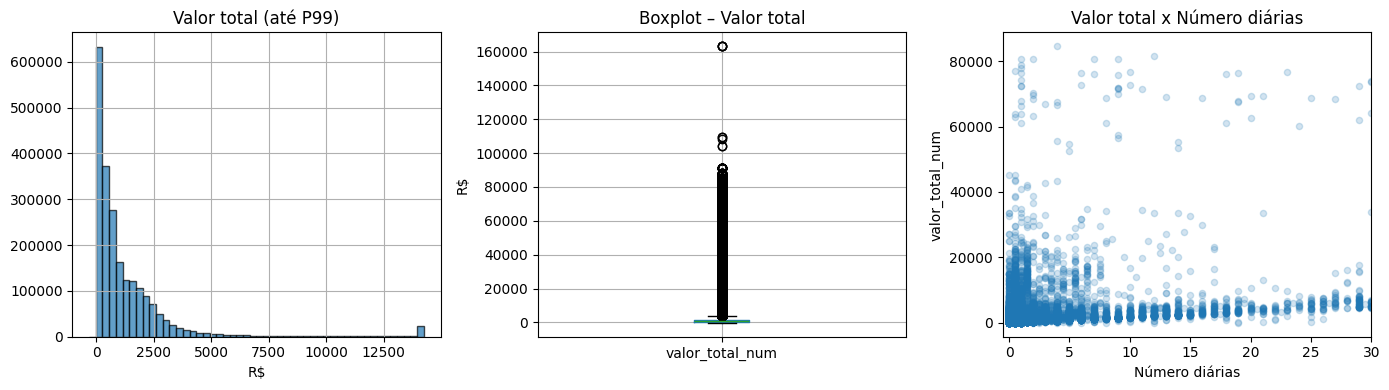

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))  # painel principal da 3.2: distribuição + dispersão básica

y = df['valor_total_num'].dropna()
y99 = y.clip(upper=y.quantile(0.99))  # corto a cauda direita só no desenho — histograma não fica esmagado pelos outliers
y99.hist(ax=axes[0], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('Valor total (até P99)')
axes[0].set_xlabel('R$')

df.boxplot(column='valor_total_num', ax=axes[1])  # mesma variável sem clip: dá para ver outliers além dos bigodes
axes[1].set_title('Boxplot – Valor total')
axes[1].set_ylabel('R$')

col_nd = col_num_diarias if col_num_diarias in df.columns else COLS_NUM[-1] if COLS_NUM else 'valor_total_num'  # fallback se nome da coluna de diárias mudar
amostra = df[[col_nd, 'valor_total_num']].dropna().sample(n=min(50000, len(df)), random_state=42)  # 50k pontos bastam pra ver a nuvem sem travar
amostra.plot.scatter(x=col_nd, y='valor_total_num', alpha=0.2, ax=axes[2])
axes[2].set_xlim(-0.5, 30)  # acima de ~30 diárias quase não há massa — zoom na parte útil
axes[2].set_title('Valor total x Número diárias')
plt.tight_layout()
plt.show()



#### Painel complementar

Gráficos adicionais apoiam a **discussão** (sazonalidade, efeito de **Motivo**, composição diárias/passagem e coerência com **duração**). Correlações no heatmap repetem em forma visual o que a tabela da **3.1.2** já quantifica.


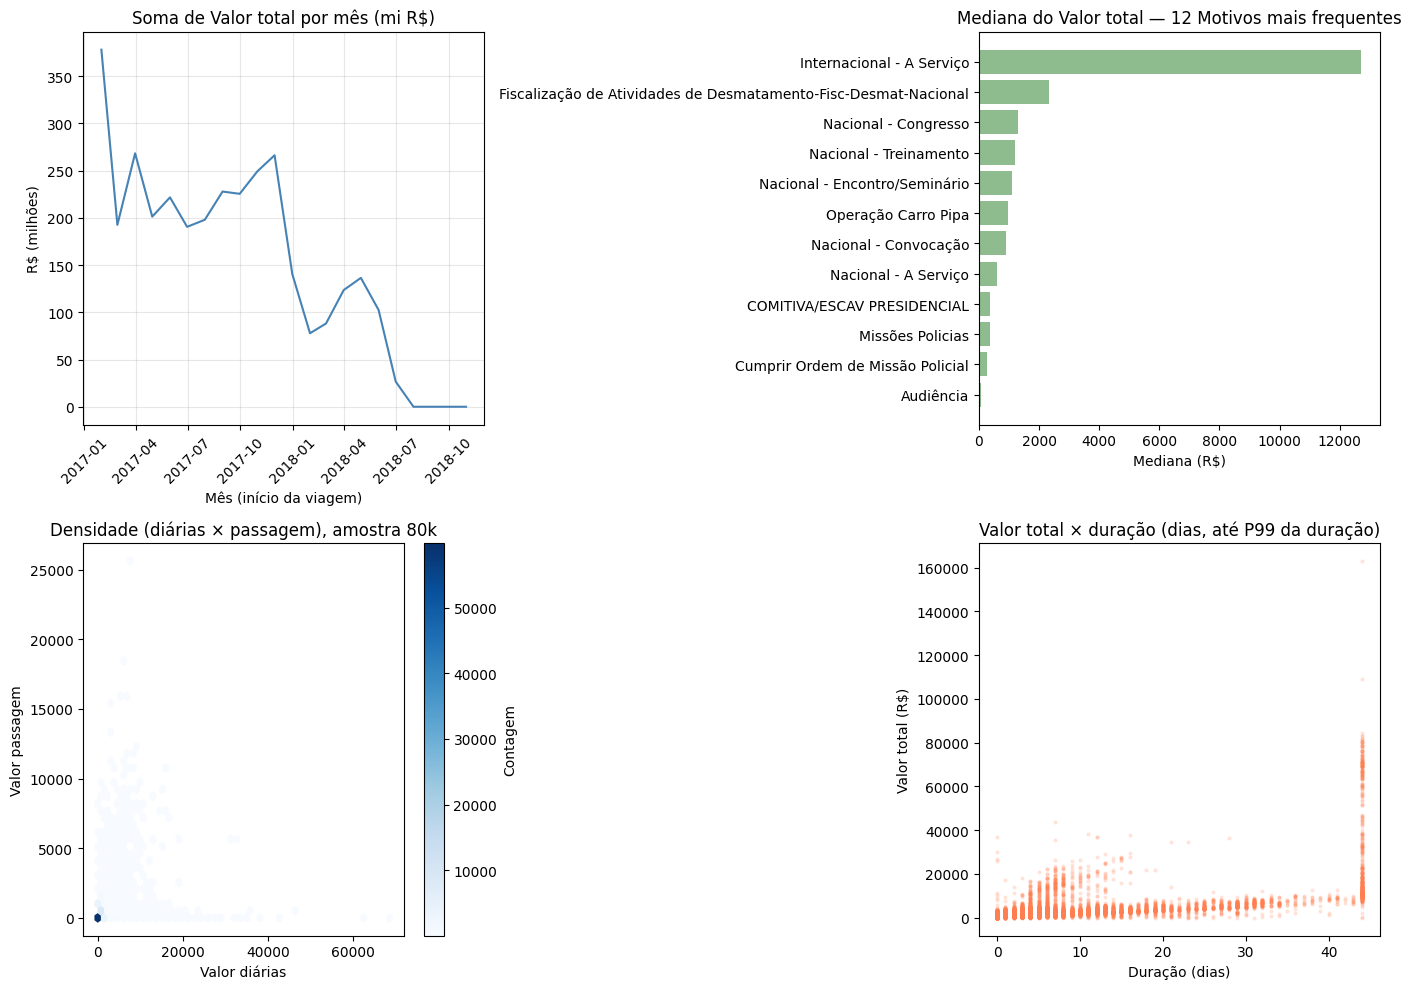

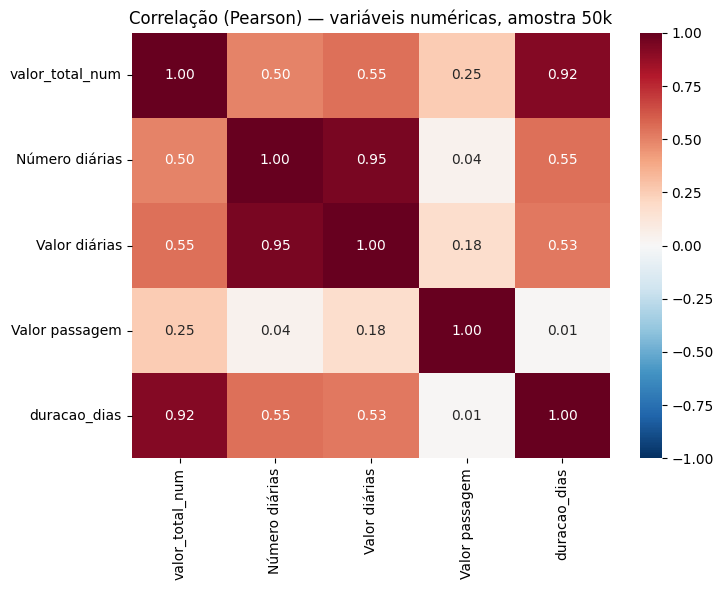

In [8]:
# Painel extra da 3.2 — depende das colunas já criadas acima (valores numéricos, datas, duracao_dias, acha_col)
fig2, axes2 = plt.subplots(2, 2, figsize=(14, 10))

# 1) Gasto agregado por mês (soma do Valor total) — vê tendência / sazonalidade grosseira
dt_col = next((c for c in df.columns if "início" in c.lower() and "viagem" in c.lower()), "Data início viagem")
mensal = (
    df.dropna(subset=[dt_col])
    .groupby(pd.Grouper(key=dt_col, freq="ME"), dropna=False)["valor_total_num"]
    .sum()
    / 1e6  # escala em milhões de reais pra legenda não ficar com muitos zeros
)
axes2[0, 0].plot(mensal.index, mensal.values, color="steelblue")
axes2[0, 0].set_title("Soma de Valor total por mês (mi R$)")
axes2[0, 0].set_xlabel("Mês (início da viagem)")
axes2[0, 0].set_ylabel("R$ (milhões)")
axes2[0, 0].tick_params(axis="x", rotation=45)
axes2[0, 0].grid(True, alpha=0.3)

# 2) Motivo: pego os 12 mais frequentes e comparo mediana do alvo (robusto à cauda)
col_mot = acha_col(df, "Motivo")
if col_mot is None:
    col_mot = "Motivo"
top_motivos = df[col_mot].value_counts().head(12).index
sub_m = df[df[col_mot].isin(top_motivos)]
med_m = sub_m.groupby(col_mot, observed=False)["valor_total_num"].median().sort_values()
axes2[0, 1].barh(med_m.index.astype(str), med_m.values, color="darkseagreen")
axes2[0, 1].set_title("Mediana do Valor total — 12 Motivos mais frequentes")
axes2[0, 1].set_xlabel("Mediana (R$)")

# 3) Muitos pontos sobrepostos — hexbin em amostra mostra onde está a densidade (muito passagem zero + diárias)
cols_hex = [c for c in [col_valor_diarias, col_valor_passagem] if c and c in df.columns]
if len(cols_hex) == 2:
    am_hex = df[cols_hex + ["valor_total_num"]].dropna().sample(n=min(80_000, len(df)), random_state=43)
    hb = axes2[1, 0].hexbin(
        am_hex[cols_hex[0]],
        am_hex[cols_hex[1]],
        gridsize=45,
        cmap="Blues",
        mincnt=1,
        linewidths=0.1,
    )
    plt.colorbar(hb, ax=axes2[1, 0], label="Contagem")
    axes2[1, 0].set_xlabel(col_valor_diarias)
    axes2[1, 0].set_ylabel(col_valor_passagem)
    axes2[1, 0].set_title("Densidade (diárias × passagem), amostra 80k")
else:
    axes2[1, 0].text(0.5, 0.5, "Colunas de valor não encontradas", ha="center", va="center")
    axes2[1, 0].set_axis_off()

# 4) Duração vs alvo: corto o eixo X no P99 da duração pra não dominar por poucas viagens absurdamente longas
if "duracao_dias" in df.columns:
    am_d = df[["duracao_dias", "valor_total_num"]].dropna().sample(n=min(50_000, len(df)), random_state=44)
    cap_x = am_d["duracao_dias"].quantile(0.99)
    axes2[1, 1].scatter(
        am_d["duracao_dias"].clip(upper=cap_x),
        am_d["valor_total_num"],
        alpha=0.15,
        s=4,
        c="coral",
    )
    axes2[1, 1].set_title("Valor total × duração (dias, até P99 da duração)")
    axes2[1, 1].set_xlabel("Duração (dias)")
    axes2[1, 1].set_ylabel("Valor total (R$)")
else:
    axes2[1, 1].text(0.5, 0.5, "Coluna duracao_dias ausente (rode a célula de correlação/datas)", ha="center", va="center")
    axes2[1, 1].set_axis_off()

plt.tight_layout()
plt.show()

# Heatmap: mesma informação que a tabela da 3.1.2, mas numa figura só pro relatório
cols_hm = [
    c
    for c in [
        "valor_total_num",
        col_num_diarias,
        col_valor_diarias,
        col_valor_passagem,
        "duracao_dias",
    ]
    if c and c in df.columns
]
sam_hm = df[cols_hm].dropna().sample(n=min(50_000, len(df)), random_state=45)
cm = sam_hm.corr(numeric_only=True)
fig3, ax_hm = plt.subplots(figsize=(7.5, 6))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax_hm)
ax_hm.set_title("Correlação (Pearson) — variáveis numéricas, amostra 50k")
plt.tight_layout()
plt.show()



**Leitura dos gráficos**

- **Histograma (Valor total até P99):** No eixo horizontal estão faixas de valor em R$; no vertical, a quantidade de registros em cada faixa. A forma da distribuição mostra onde a maioria dos gastos se concentra (ex.: pico em valores baixos) e se há **assimetria** (cauda longa para a direita indica muitos valores altos). Valores acima do P99 foram cortados para não comprimir a visualização da parte central.  
  **O que está significando:** A maior parte das despesas tende a ficar em faixas mais baixas (viagens curtas ou só diárias), enquanto uma minoria de registros puxa a média para cima (viagens longas ou com passagens caras). Isso indica que o **target (Valor total) não é simétrico** e que na regressão pode ser útil usar **transformação** (ex.: log) ou tratar outliers para o modelo não ser dominado por poucos valores muito altos.

- **Boxplot (Valor total):** A caixa representa o intervalo entre Q1 e Q3 (25% e 75%); a linha dentro da caixa é a **mediana**. Os “bigodes” vão até 1,5× a amplitude interquartílica; pontos além deles são **outliers**.  
  **O que está significando:** A mediana indica o valor "típico" de uma despesa; a caixa mostra onde está concentrada a metade central dos dados. Muitos **pontos acima do bigode** significam que há **gastos atípicos** (possíveis viagens de alto custo ou erros de lançamento). Para a modelagem, isso reforça a necessidade de decidir se esses valores serão mantidos, limitados (cap) ou se o modelo será ajustado em log(Valor total) para reduzir o peso dos extremos.

- **Dispersão (Número diárias × Valor total):** Cada ponto é um registro (amostra). No eixo X está o número de diárias; no Y, o valor total em R$. Uma **nuvem com tendência ascendente** indica que, em média, mais diárias estão associadas a maior gasto; a espessura da nuvem mostra a **variabilidade**.  
  **O que está significando:** A tendência positiva indica que **Número diárias** é uma preditora relevante para o Valor total (mais dias de viagem, em geral, mais custo). A **dispersão em torno da tendência** significa que o valor não depende só do número de diárias: **motivo da viagem, meio de transporte, órgão e destino** também influenciam. Na prática, o modelo de regressão deve incluir essas outras variáveis para prever melhor; usar só Número diárias tende a deixar grande parte da variação sem explicação.

- **Série mensal (soma em mi R$):** mostra **tendência e sazonalidade** do gasto agregado por mês de início da viagem; quedas ou picos podem refletir calendário administrativo, conjuntura ou mudanças de divulgação dos dados, não só "menos viagens".
- **Mediana por Motivo:** compara o Valor total **típico** entre os motivos mais comuns; medianas muito diferentes sugerem que **Motivo** será preditora relevante na regressão (além de Número diárias).
- **Hexbin (diárias × passagem):** concentração perto de **passagem zero** é esperada (muitos registros só com diária); faixas com passagem alta aparecem como nuvem à direita ou acima, mostrando a **composição** do custo.
- **Duração × Valor total:** tendência positiva reforça que viagens **mais longas** costumam custar mais; o corte no P99 da duração evita que poucos trechos extremos esmagem o eixo horizontal.
- **Heatmap de correlação:** resume relações lineares entre numéricas; é coerente com os valores numéricos da **3.1.2** e facilita **uma figura única** para o relatório.


## 4. Discussão Preliminar

Com base nas seções 3.1 (incluindo **3.1.1** valores ausentes e **3.1.2** correlação) e **3.2**, destaque:

**Padrões e relações:** A variável **Valor total** costuma apresentar **forte assimetria positiva** (média bem acima da mediana) e alto **CV%**, com outliers visíveis no boxplot. O gráfico **Número diárias × Valor total** tende a mostrar **relação positiva**, mas com muita variabilidade, sugerindo que Motivo, Meio de transporte e órgão serão importantes. **Valor passagem** é zero em muitos registros (apenas diária); quando há passagem, os valores podem ser elevados.

**Qualidade dos dados:** Cargo tem elevada proporção de nulos; **Município/UF** e **Categoria passagem** têm muitos nulos quando não há trecho de passagem. Colunas monetárias e Número diárias exigem conversão de vírgula para ponto (feita na carga); datas devem ser convertidas para datetime para derivar duração e mês/ano. Duplicatas foram removidas.

**Enquadramento e timing administrativo (seção 1):** Os valores são **indenizações** por viagem a serviço (Lei 8.112/1990), registrados como **lançamentos** no ecossistema SCDP/dados abertos. A **data de início** da viagem **não** coincide necessariamente com o **pagamento** de diárias ou com o **registro da emissão** de passagens; viagens **sigilosas** podem entrar tarde em bases públicas. Por isso, agregações por período e o uso de datas como preditoras pedem **interpretação prudente** (o modelo vê o que está na tabela, não o fluxo administrativo completo).

**Implicações para a modelagem:** Considerar transformação no target (ex.: log(1+y)); encoding para Motivo e Meio de transporte; agrupamento de categorias raras; decisão sobre subconjunto (todos vs. só com passagem) e validação temporal (treino/teste por período).

---

## 5. Próximos Passos

**Ajustes nos dados:** Garantir datas em datetime e criar duração da viagem, mês e ano; tratar nulos em Cargo, Município/UF e Categoria passagem; agrupar categorias raras em Motivo e Meio de transporte; avaliar transformação no target (log) ou tratamento de outliers.

**Variáveis:** Alvo = **Valor total** (regressão). Preditoras candidatas: Número diárias, duração, mês, ano, Motivo, Meio de transporte, órgão (codificado/agrupado). Evitar Nome servidor (muitas categorias).

**Encoding:** Na regressão linear, usar **one-hot com `drop_first`** nas categóricas de **baixa cardinalidade**; para nomes de órgão, UG, município ou servidor, **não** usar one-hot direto — preferir agregação, nível hierárquico (ex.: só órgão superior) ou algoritmos que suportem muitas categorias com regularização.

**Modelagem:** Split treino/validação/teste (considerar hold-out temporal). Modelos: regressão linear (baseline), árvore, random forest, gradient boosting. Métricas: RMSE, MAE, R² (e eventualmente MAPE). Pipeline com encoding e escalonamento conforme o algoritmo.

---

## Referências

- **Viagens a serviço do governo federal (SCDP)** — Dados abertos: [dados.gov.br – conjunto SCDP](https://dados.gov.br/dados/conjuntos-dados/viagens-a-servico-do-governo-federal-scdp).
- **Sistema SCDP:** [novoscdp – home](https://www2.scdp.gov.br/novoscdp/home.xhtml).
- **Portal da Transparência — Viagens a Serviço:** [visão geral](https://portaldatransparencia.gov.br/viagens/visao-geral).
- Documento do projeto: `pre_projeto_diarias_passagens.md`.